# SIPTA -- Ingesta y EDA: Infraestructura y Espacio Público (Parques IDRD)
**Proyecto**: Sistema de Indicadores y Priorización Territorial y Alertas Tempranas (DataJam Bogotá)  
**Fase PDCO**: DEVELOPMENT | **Fase CRISP-DM**: Data Understanding / Data Preparation  
**Autoría**: **Persona A (Adan Sánchez -- Lead Data Engineer & Autor de EDA)**  
**Objetivo**: Ingesta de parques distritales IDRD, equipamientos asistenciales y análisis exploratorio de espacio público (EDA).  
**Datos de Entrada**: `data/raw/INFRAESTRUCTURA_ESPACIO_PUBLICO/*`  
**Datos de Salida**: `data/processed/INFRAESTRUCTURA_ESPACIO_PUBLICO/*`


## 1. Ingesta y Normalización de Parques y Equipamientos



In [ ]:
import sys
from pathlib import Path
import pandas as pd

for p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (p / 'src').exists():
        ROOT = p
        if str(ROOT) not in sys.path:
            sys.path.insert(0, str(ROOT))
        break
RAW_DIR = ROOT / 'data' / 'raw' / 'INFRAESTRUCTURA_ESPACIO_PUBLICO'
PROCESSED_DIR = ROOT / 'data' / 'processed' / 'INFRAESTRUCTURA_ESPACIO_PUBLICO'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Carga de Parques IDRD
df_parques = pd.read_csv(RAW_DIR / '5.-parques-idrd.csv', sep=';', encoding='latin1')
print('Parques IDRD Shape:', df_parques.shape)
display(df_parques.head())

# Exportación
df_parques.to_csv(PROCESSED_DIR / '5.-parques-idrd.csv', index=False, sep=';', encoding='utf-8')
print('Datos de parques persistidos en data/processed/INFRAESTRUCTURA_ESPACIO_PUBLICO/')




## 2. Análisis Exploratorio de Espacio Verde y Recreación



# 05 · EDA Infraestructura y espacio público

Cuatro fuentes en `data/raw/INFRAESTRUCTURA_ESPACIO_PUBLICO/`:
- `5.-parques-idrd.csv` -- parques del IDRD (139 registros, 5 columnas).
- `estado/Estado.csv` -- estado superficial de la malla vial (104.550 tramos, sin georreferencia).
- `ips.gpkg` -- IPS georreferenciadas (misma fuente REPS que salud, capa `ips`).
- `gpkg_mr_v03.26/gpkg_mr_v03.26.gpkg` -- **mapa de referencia (MR)** con 41 capas: se usa como
  base cartográfica para los cruces espaciales (capa `Loca`), no como fuente de indicadores.

**Indicadores objetivo**: INF-01 (parques por localidad), INF-02 (espacio público efectivo),
INF-03 (estado de la malla vial).

## 0. Configuración

In [ ]:
import sys, os, re, json, warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
warnings.filterwarnings("ignore")

# Búsqueda universal de la raíz del proyecto (Local, Subdirectorios y Google Colab)
ROOT = None
for _p in [Path(".").resolve(), Path("..").resolve(), Path("../..").resolve(), Path("/content/DataJam_DataOlinguitos_Gen"), Path("/content")]:
    if (_p / "src" / "eda").exists() or (_p / "src").exists():
        ROOT = _p
        break

if ROOT is None:
    ROOT = Path(".").resolve()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RAW_DIR = ROOT / "data" / "raw"
MR_PATH = RAW_DIR / "INFRAESTRUCTURA_ESPACIO_PUBLICO" / "gpkg_mr_v03.26" / "gpkg_mr_v03.26.gpkg"
REPORTS = ROOT / "reports" / "eda"
PERFILES = REPORTS / "perfiles"
CACHE = REPORTS / "cache"
TIEMPOS = REPORTS / "tiempos"
for _d in (REPORTS, PERFILES, CACHE, TIEMPOS):
    _d.mkdir(parents=True, exist_ok=True)

SMOKE = os.environ.get("EDA_SMOKE") == "1"
print("ROOT:", ROOT, "| SMOKE:", SMOKE)

import src.eda as eda
from src.eda.explore import explorar_dataset

_SECTION_T = {}

def t0(nombre):
    _SECTION_T[nombre] = time.time()

def t1(nombre):
    _SECTION_T[nombre] = time.time() - _SECTION_T[nombre]

def guardar_tiempos(archivo):
    df = pd.DataFrame([{"seccion": k, "segundos": round(v, 1)} for k, v in _SECTION_T.items()])
    df.to_csv(TIEMPOS / archivo, index=False)
    print(f"tiempos guardados: {archivo} ({len(df)} secciones)")


ROOT: C:\Users\ADAN\DataJam_DataOlinguitos_Gen | SMOKE: False


## 0.1 Fuentes del sector en el catálogo

In [ ]:
cat = eda.load_catalog()
sec = cat[cat["indicadores"].astype(str).str.contains("INF", case=False, na=False)]
display(sec[["id", "nombre", "archivo", "temporalidad", "indicadores", "valor_publico"]])


,id,nombre,archivo,temporalidad,indicadores,valor_publico


## 1. Parques IDRD

### Parques IDRD

### Parques IDRD

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,Codigo Parque,str,id/llave,0,0.0,135,01-012,01-023,01-064
1,Nombre Parque,str,categórica nominal,0,0.0,138,La Vida,Servita,Nueva Autopista
2,Nombre Localidad,str,categórica nominal,0,0.0,19,USAQUÉN,CHAPINERO,SANTA FE
3,Tipologia,str,categórica nominal,0,0.0,1,ESTRUCTURANTE,,
4,Administracion,str,categórica nominal,0,0.0,1,IDRD,,


,columna,n,n_nulos,n_categorias,dominante,pct_dominante,top_5
0,Codigo Parque,139,0,135,04-127,1.44,04-127=2 | 06-063=2 | 11-368=2 | 11-204=2 | 01...
1,Nombre Parque,139,0,138,Arborizadora Alta,1.44,Arborizadora Alta=2 | La Vida=1 | Servita=1 | ...
2,Nombre Localidad,139,0,19,CIUDAD BOLIVAR,10.07,CIUDAD BOLIVAR=14 | KENNEDY=13 | ENGATIVÁ=13 |...
3,Tipologia,139,0,1,ESTRUCTURANTE,100.00,ESTRUCTURANTE=139
4,Administracion,139,0,1,IDRD,100.00,IDRD=139


Sin columnas con nulos.


## Interpretación -- Parques IDRD

**Origen**: Instituto Distrital de Recreación y Deporte (IDRD) -- datos abiertos  
**Corte temporal**: Vigente  
**Valor público**: Cobertura y déficit de espacio público de recreación por localidad

**Qué contiene**: 139 filas y 5 columnas; 0.0% de celdas nulas y 0 duplicados.
Columnas territoriales detectadas: **Nombre Localidad**.

**Categóricas dominantes**:
- `Codigo Parque`: 135 categorías; dominante '04-127' (1%)
- `Nombre Parque`: 138 categorías; dominante 'Arborizadora Alta' (1%)
- `Nombre Localidad`: 19 categorías; dominante 'CIUDAD BOLIVAR' (10%)
- `Tipologia`: 1 categorías; dominante 'ESTRUCTURANTE' (100%)

**Cobertura territorial**: 19 localidades con dato (de 20 + Bogotá).

**Notas / qué falta**: 139 parques, 5 columnas, con Nombre Localidad. Sin área en m2: INF-02 requiere cruce con el MR.

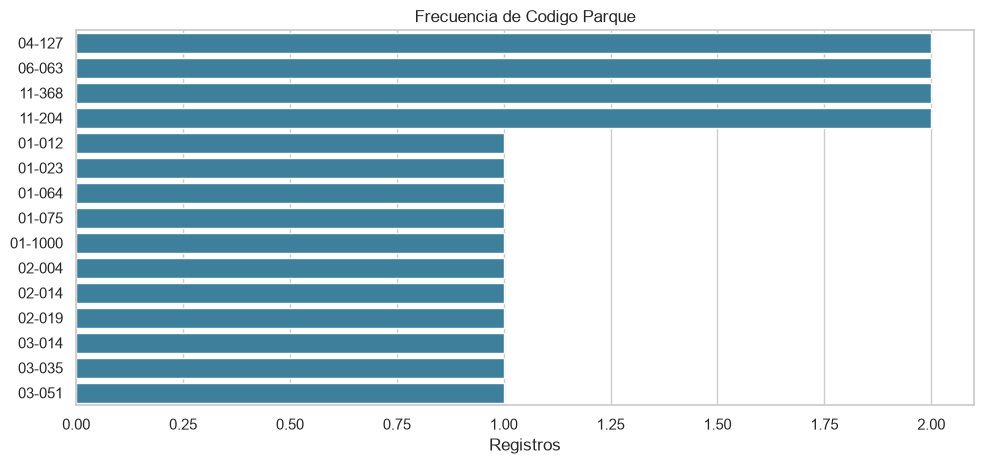

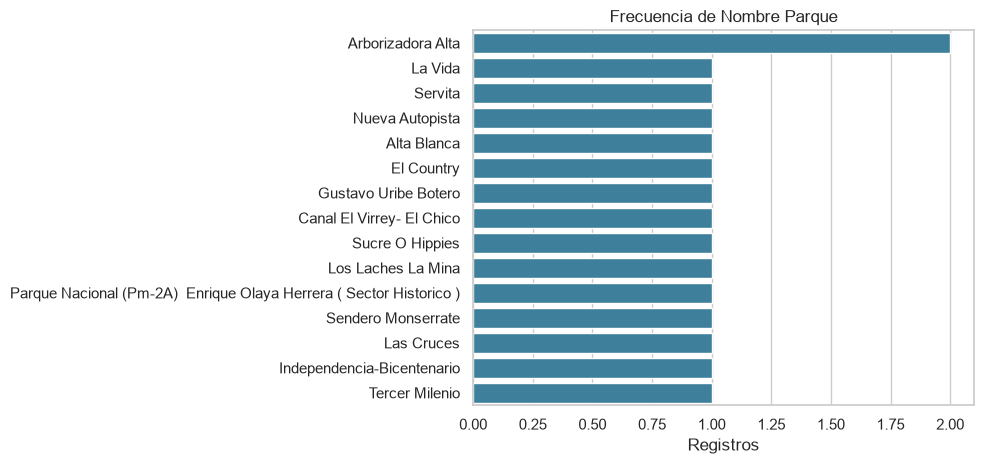

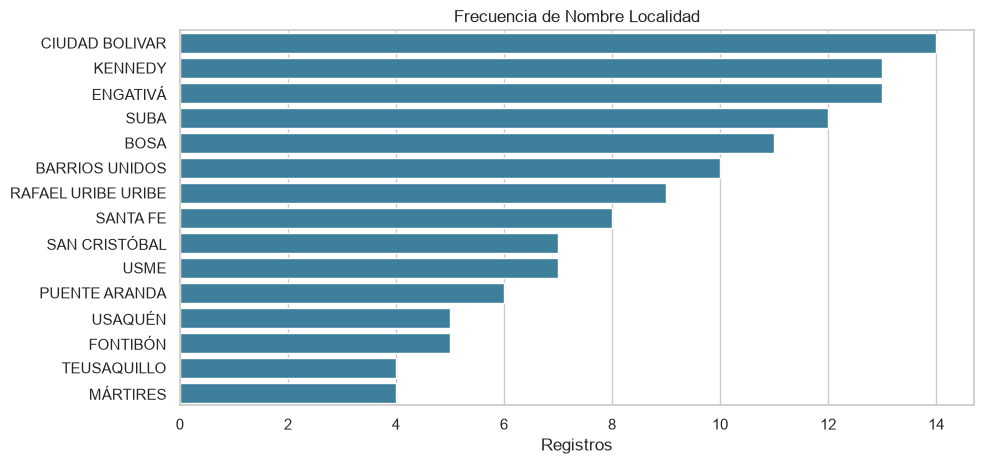

In [ ]:
t0('parques')
SPEC = {
    'id': 'parques_idrd',
    'titulo': 'Parques IDRD',
    'path': 'data/raw/INFRAESTRUCTURA_ESPACIO_PUBLICO/5.-parques-idrd.csv',
    'origen': 'Instituto Distrital de Recreación y Deporte (IDRD) -- datos abiertos',
    'corte': 'Vigente',
    'valor_publico': 'Cobertura y déficit de espacio público de recreación por localidad',
    'indicadores': 'INF-01 (parques por localidad), INF-02 (espacio público efectivo)',
    'notas': '139 parques, 5 columnas, con Nombre Localidad. Sin área en m2: INF-02 requiere cruce con el MR.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('parques')


## 2. Estado de la malla vial

### Estado superficial de vías

### Estado superficial de vías

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,OBJECTID,int64,id/llave,0,0.0,104550,1,2,3
1,ESTADO_SUPERFICIAL,int64,numérica discreta,0,0.0,9,2,3,1
2,FECHA_ESTADO,str,temporal,0,0.0,1,2025/12/31 00:00:00,,
3,CalCodigo,int64,id/llave,0,0.0,104550,160491,415491,137816


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,OBJECTID,104550,0,0.0,104550.0,5.227550e+04,52275.5,1.0,3.018113e+04,1.0,...,0.0000,-1.2000,57.7348,0.0,0.00,False,NaN,NaN,NaN,NaN
1,ESTADO_SUPERFICIAL,104550,0,0.0,9.0,2.170000e+00,2.0,2.0,1.405800e+00,1.0,...,2.1575,4.6134,64.7834,11590.0,11.09,False,NaN,NaN,NaN,NaN
2,FECHA_ESTADO,104550,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,2025/12/31 00:00:00,100.0,2025/12/31 00:00:00=104550
3,CalCodigo,104550,0,0.0,104550.0,1.653689e+07,359605.5,8501.0,3.413043e+07,8501.0,...,1.6988,0.9359,206.3897,21113.0,20.19,False,NaN,NaN,NaN,NaN


No hay valores numéricos para FECHA_ESTADO.
Sin columnas con nulos.


## Interpretación -- Estado superficial de vías

**Origen**: IDU / datos abiertos  
**Corte temporal**: 31 dic 2025 (columna FECHA_ESTADO)  
**Valor público**: Estado de la malla vial por tramo (CalCodigo)

**Qué contiene**: 104,550 filas y 4 columnas; 0.0% de celdas nulas y 0 duplicados.

**Comportamiento de variables numéricas**:
- `OBJECTID`: media 52,275.5, mediana 52,275.5, desv 30,181.1, rango [1, 104,550], curtosis -1.2 -- variabilidad alta (CV=58%)
- `ESTADO_SUPERFICIAL`: media 2.2, mediana 2.0, desv 1.4, rango [1, 13], curtosis +4.6 -- variabilidad alta (CV=65%); asimetría positiva (+2.16); 11590.0 outliers IQR (11%)
- `FECHA_ESTADO`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `CalCodigo`: media 16,536,888.9, mediana 359,605.5, desv 34,130,434.3, rango [8,501, 92,088,248], curtosis +0.9 -- variabilidad alta (CV=206%); asimetría positiva (+1.70); 21113.0 outliers IQR (20%)

**Categóricas dominantes**:
- `FECHA_ESTADO`: 1.0 categorías; dominante '2025/12/31 00:00:00' (100%)

**Notas / qué falta**: 104.550 tramos, 4 columnas. Sin georreferenciación: no desagregable por localidad.

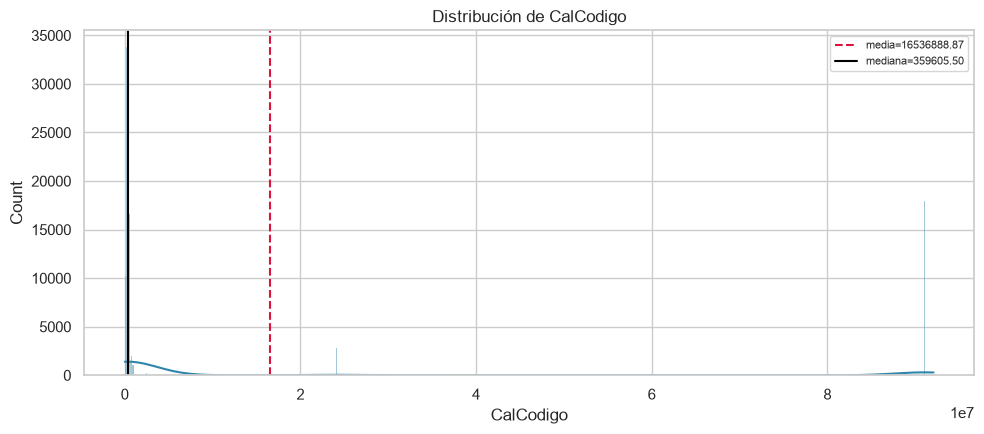

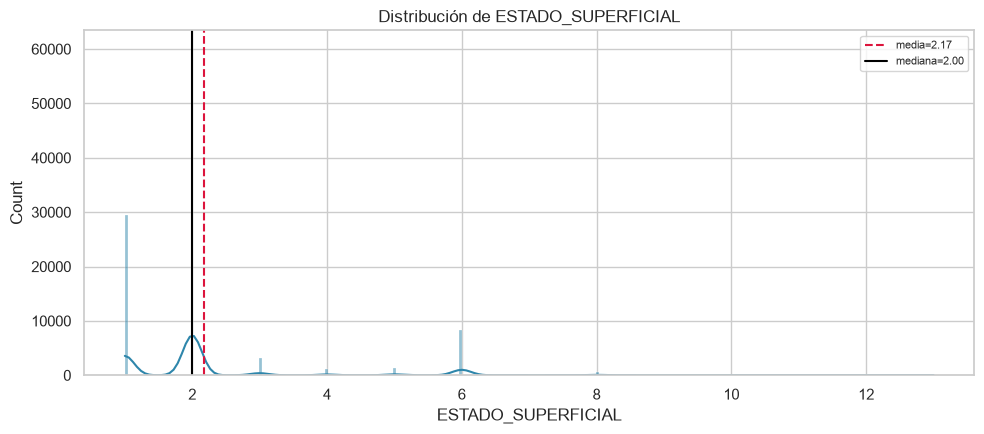

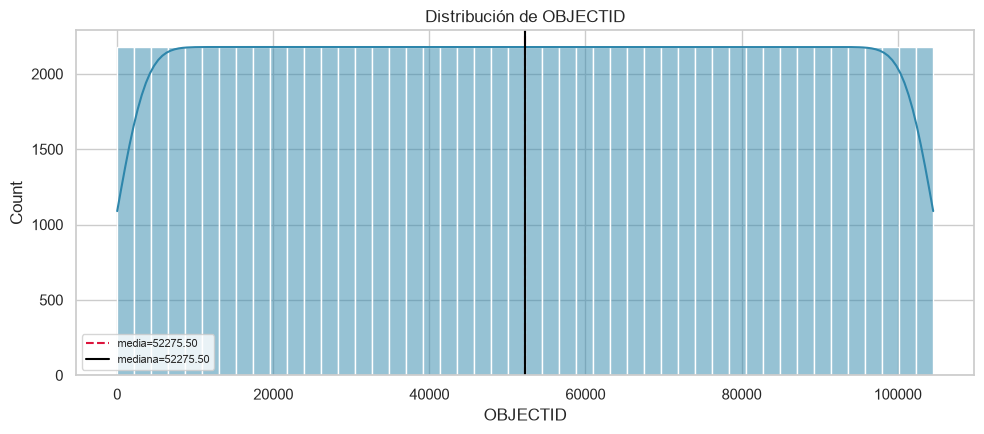

In [ ]:
t0('estado_vias')
SPEC = {
    'id': 'estado_malla_vial',
    'titulo': 'Estado superficial de vías',
    'path': 'data/raw/INFRAESTRUCTURA_ESPACIO_PUBLICO/estado/Estado.csv',
    'origen': 'IDU / datos abiertos',
    'corte': '31 dic 2025 (columna FECHA_ESTADO)',
    'valor_publico': 'Estado de la malla vial por tramo (CalCodigo)',
    'indicadores': 'INF-03 (estado de malla vial)',
    'notas': '104.550 tramos, 4 columnas. Sin georreferenciación: no desagregable por localidad.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('estado_vias')


## 3. IPS (infraestructura)

### IPS georreferenciadas (infraestructura)

### IPS georreferenciadas (infraestructura)

,columna,dtype,tipo_variable,n_nulos,pct_nulos,n_unicos,ejemplo_1,ejemplo_2,ejemplo_3
0,OBJECTID,int64,id/llave,0,0.0,2900,1,2,3
1,Id,float64,id/llave,0,0.0,2900,1.0,2.0,3.0
2,departamen,str,categórica nominal,0,0.0,1,Bogotá D.C,,
3,municipio,str,categórica nominal,0,0.0,1,BOGOTÁ,,
4,codigo_pre,str,categórica nominal,0,0.0,1527,1100100032,1100100103,1100100130
5,nombre_pre,str,categórica nominal,0,0.0,1527,COOPERATIVA PARA LA SALUD ORAL ORALCOOP,INSTITUTO NACIONAL DEL RIÑON LTDA,INVERSIONES DAMA SALUD SAS
6,nombre,str,categórica nominal,0,0.0,2676,COOPERATIVA PARA LA SALUD ORAL ORALCOOP,INSTITUTO NACIONAL DEL RIÑON LTDA,SONRIA DAMA SALUD SEDE RESTREPO
7,tipo_zona,str,categórica nominal,0,0.0,3,URBANA,,RURAL
8,direccion,str,categórica nominal,0,0.0,2896,KR 64 # 100 55,CLL 43 # 25 - 61,DIAGONAL 19 SUR No 20 -39
9,barrio,str,categórica nominal,0,0.0,828,SUBA,LA SOLEDAD,RESTREPO


,columna,n,n_nulos,pct_nulos,n_unicos,media,mediana,moda,desv_est,min,...,asimetria_skew,curtosis,CV_pct,n_outliers_iqr,pct_outliers,sin_valores_numericos,n_categorias,dominante,pct_dominante,top_5
0,OBJECTID,2900,0,0.0,2900.0,1.450500e+03,1450.5,1.0,8.373022e+02,1.0,...,0.0000,-1.2000,57.7251,0.0,0.00,False,NaN,NaN,NaN,NaN
1,Id,2900,0,0.0,2900.0,1.450500e+03,1450.5,1.0,8.373022e+02,1.0,...,0.0000,-1.2000,57.7251,0.0,0.00,False,NaN,NaN,NaN,NaN
2,departamen,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,Bogotá D.C,100.00,Bogotá D.C=2900
3,municipio,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,BOGOTÁ,100.00,BOGOTÁ=2900
4,codigo_pre,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1527.0,1100107335,1.69,1100107335=49 | 1100130296=44 | 1100123845=43 ...
5,nombre_pre,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1527.0,CAJA DE COMPENSACION FAMILIAR COMPENSAR,1.69,CAJA DE COMPENSACION FAMILIAR COMPENSAR=49 | S...
6,nombre,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2676.0,LAFAM OPTICAS,1.10,LAFAM OPTICAS=32 | OPTICAS GMO COLOMBIA S.A.S....
7,tipo_zona,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,URBANA,99.21,URBANA=2877 | RURAL=20 | =3
8,direccion,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2896.0,CALLE 186 Nº 7a-57,0.07,CALLE 186 Nº 7a-57=2 | CARRERA 16 No. 82 - 57 ...
9,barrio,2900,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,828.0,SANTA BARBARA,3.41,SANTA BARBARA=99 | CHICO=86 | CHAPINERO=85 | ...


No hay valores numéricos para departamen.
No hay valores numéricos para municipio.
Sin columnas con nulos.


## Interpretación -- IPS georreferenciadas (infraestructura)

**Origen**: REPS -- Secretaría Distrital de Salud  
**Corte temporal**: Corte REPS  
**Valor público**: Equipamientos de salud como parte del inventario de infraestructura

**Qué contiene**: 2,900 filas y 27 columnas; 0.0% de celdas nulas y 0 duplicados.
Capas con geometría (<StringArray>
['Point']
Length: 1, dtype: str) en CRS EPSG:4326.
Columnas territoriales detectadas: **barrio**.

**Comportamiento de variables numéricas**:
- `OBJECTID`: media 1,450.5, mediana 1,450.5, desv 837.3, rango [1, 2,900], curtosis -1.2 -- variabilidad alta (CV=58%)
- `Id`: media 1,450.5, mediana 1,450.5, desv 837.3, rango [1, 2,900], curtosis -1.2 -- variabilidad alta (CV=58%)
- `departamen`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `municipio`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)
- `codigo_pre`: media nan, mediana nan, desv nan, rango [nan, nan], curtosis +nan -- nan outliers IQR (nan%)

**Categóricas dominantes**:
- `departamen`: 1.0 categorías; dominante 'Bogotá D.C' (100%)
- `municipio`: 1.0 categorías; dominante 'BOGOTÁ' (100%)
- `codigo_pre`: 1,527.0 categorías; dominante '1100107335' (2%)
- `nombre_pre`: 1,527.0 categorías; dominante 'CAJA DE COMPENSACION FAMILIAR COMPENSAR' (2%)

**Cobertura territorial**: 17 localidades con dato (de 20 + Bogotá).

**Notas / qué falta**: Misma fuente REPS que salud/ips_sds.gpkg; EPSG:4326, sin localidad: cruce espacial.

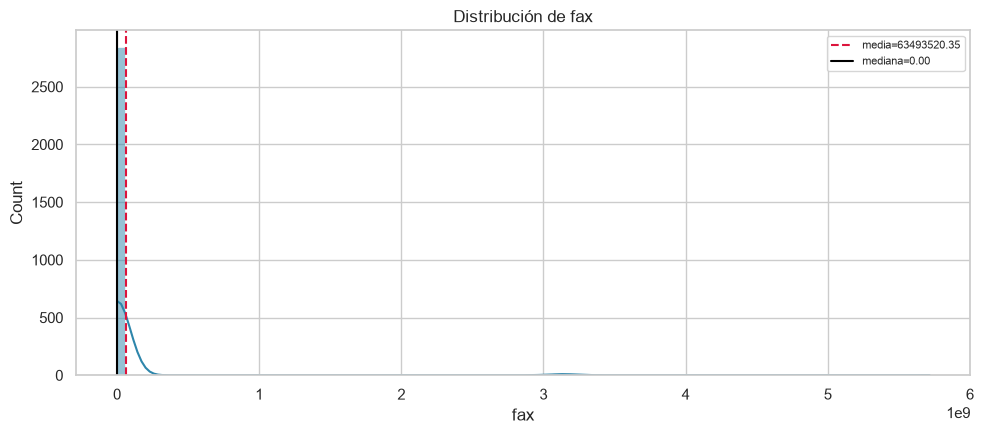

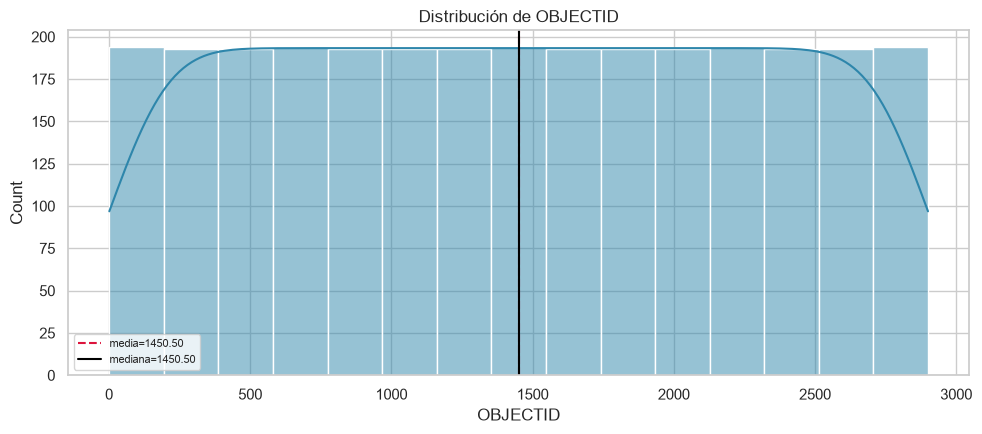

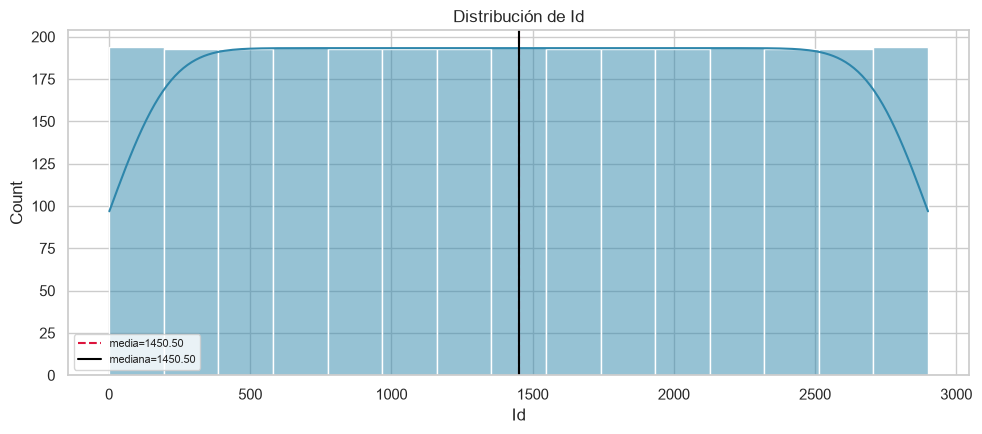

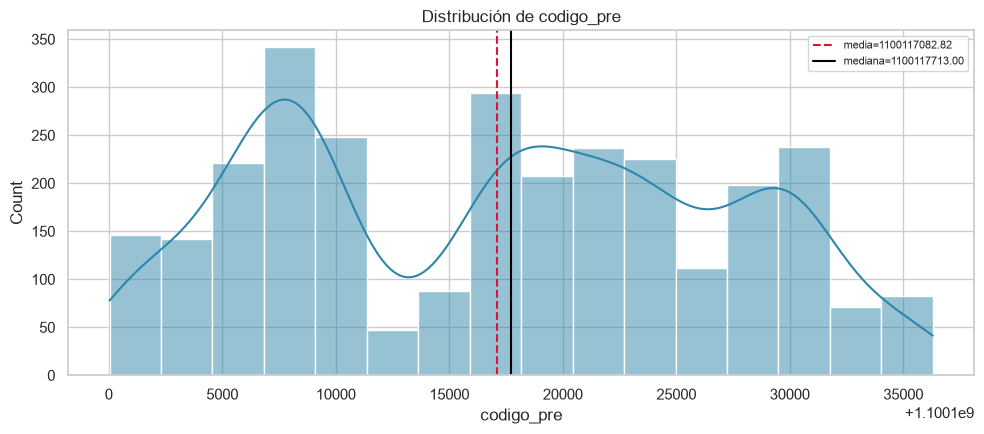

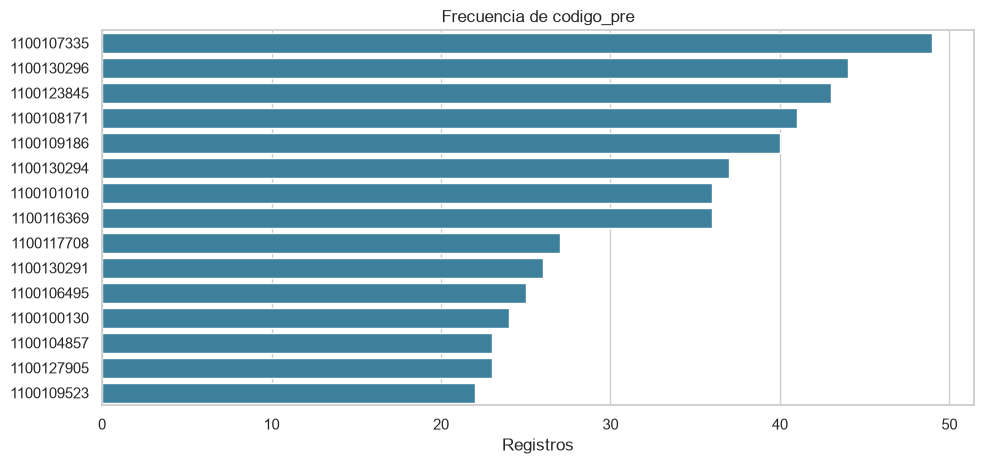

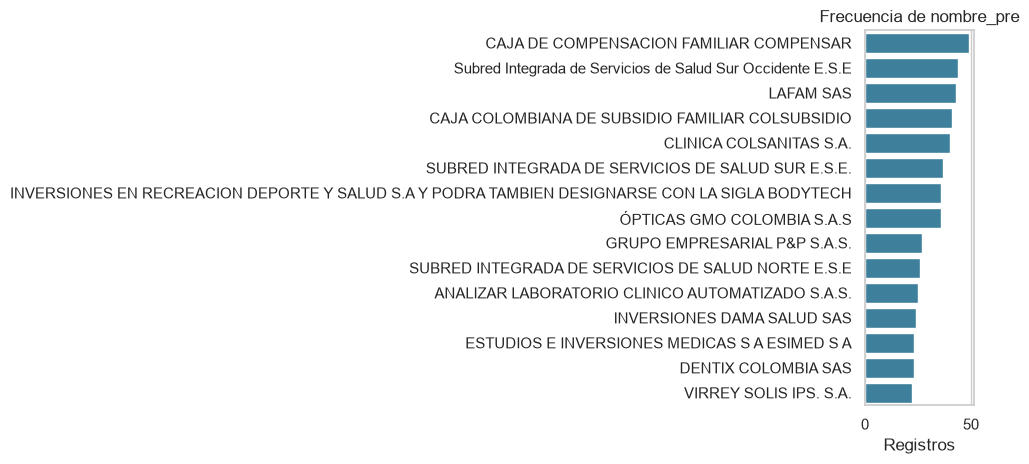

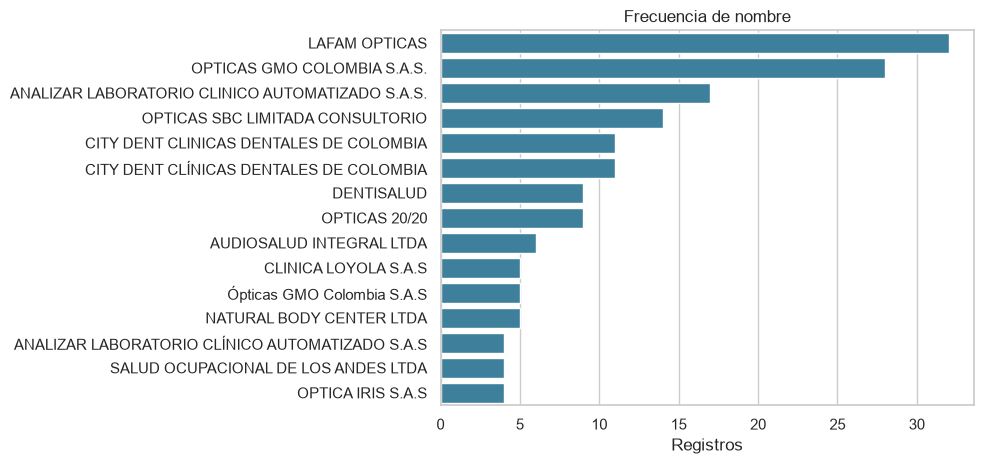

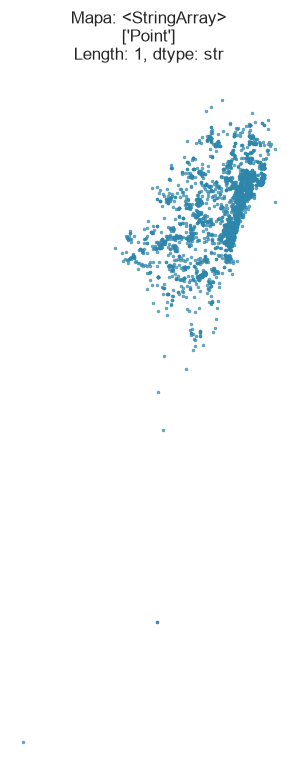

In [ ]:
t0('ips_infra')
SPEC = {
    'id': 'ips_infraestructura',
    'titulo': 'IPS georreferenciadas (infraestructura)',
    'path': 'data/raw/INFRAESTRUCTURA_ESPACIO_PUBLICO/ips.gpkg',
    'capa': 'ips',
    'origen': 'REPS -- Secretaría Distrital de Salud',
    'corte': 'Corte REPS',
    'valor_publico': 'Equipamientos de salud como parte del inventario de infraestructura',
    'indicadores': 'INF-03, SAL-01',
    'notas': 'Misma fuente REPS que salud/ips_sds.gpkg; EPSG:4326, sin localidad: cruce espacial.',
}
RES = explorar_dataset(SPEC, RAW_DIR, PERFILES, smoke=SMOKE)
t1('ips_infra')


## 4. Mapa de referencia (MR)

El MR (41 capas) es la base cartográfica del proyecto. Solo se perfilan metadatos y se cargan las capas de localidades (`Loca`).

### 4.1 Inventario de capas del MR

In [ ]:
from src.eda.quality import profile_file
entradas = profile_file(MR_PATH, ROOT / "data", smoke=True)
mr_tabla = pd.DataFrame(entradas)
mr_tabla.to_csv(REPORTS / "mr_metadatos_capas.csv", index=False)
cols_mostrar = [c for c in ["capa_hoja", "tipo_geometria", "filas_totales", "columnas", "pct_nulos_total"] if c in mr_tabla.columns]
display(mr_tabla[cols_mostrar])
print(f"Capas del MR: {len(mr_tabla)}")


,capa_hoja,filas_totales,columnas,pct_nulos_total
0,Manz,44414,4,NaN
1,Lote,933426,8,NaN
2,SCat,1217,5,NaN
3,Cons,2415108,11,NaN
4,CDAg,13252,14,NaN
5,CNiv,1575,5,NaN
6,Muni,1,6,0.00
7,Loca,20,6,0.00
8,Corr,3,5,NaN
9,CPob,11,5,NaN


Capas del MR: 41


### 4.2 Localidades (capa Loca)

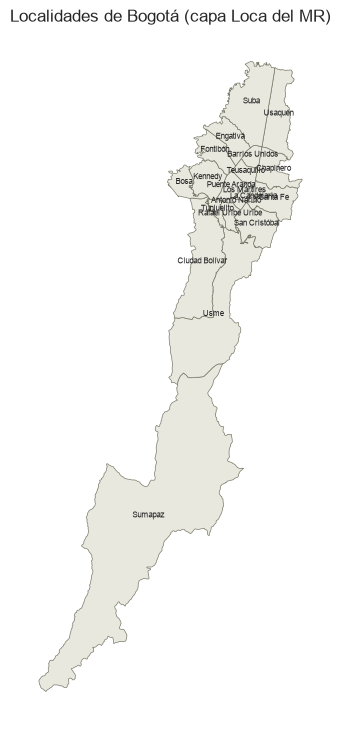

             localidad
0       Antonio Nariño
1           Tunjuelito
2   Rafael Uribe Uribe
3        La Candelaria
4       Barrios Unidos
5          Teusaquillo
6        Puente Aranda
7         Los Mártires
8              Sumapaz
9              Usaquén
10           Chapinero
11            Santa Fe
12       San Cristóbal
13                Usme
14      Ciudad Bolívar
15                Bosa
16             Kennedy
17            Fontibón
18            Engativá
19                Suba


In [ ]:
from src.eda.spatial import load_loca
loca = load_loca(MR_PATH)
fig, ax = plt.subplots(figsize=(9, 9))
loca.plot(ax=ax, color="#e8e8df", edgecolor="#7a7a6a", linewidth=0.5)
for _, r in loca.iterrows():
    ax.annotate(r["localidad"], (r.geometry.centroid.x, r.geometry.centroid.y), fontsize=6, ha="center")
ax.set_title("Localidades de Bogotá (capa Loca del MR)")
ax.set_axis_off()
plt.show()
print(loca[["localidad"]].head(21).to_string())


## 5. Análisis de infraestructura

### 5.1 Parques por localidad

columnas: ['Codigo Parque', 'Nombre Parque', 'Nombre Localidad', 'Tipologia', 'Administracion']


Nombre Localidad
CIUDAD BOLIVAR        14
ENGATIVÁ              13
KENNEDY               13
SUBA                  12
BOSA                  11
BARRIOS UNIDOS        10
RAFAEL URIBE URIBE     9
SANTA FE               8
SAN CRISTÓBAL          7
USME                   7
PUENTE ARANDA          6
FONTIBÓN               5
USAQUÉN                5
TEUSAQUILLO            4
MÁRTIRES               4
ANTONIO NARIÑO         3
CHAPINERO              3
TUNJUELITO             3
LA CANDELARIA          2
Name: parques, dtype: int64

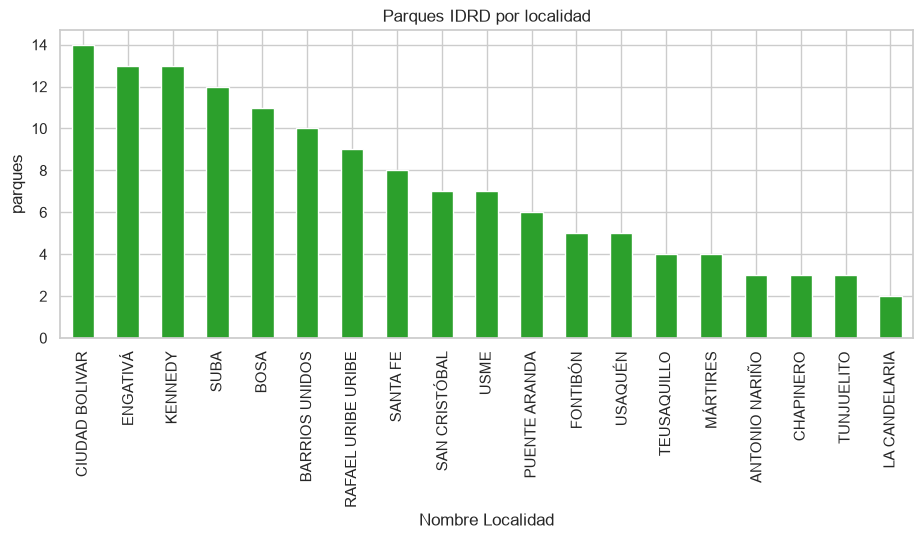

Total parques: 139 | localidades con parques: 19 | sin parques: 1


In [ ]:
parq = eda.read_csv_robust(str(RAW_DIR / "INFRAESTRUCTURA_ESPACIO_PUBLICO" / "5.-parques-idrd.csv"))[0]
print("columnas:", list(parq.columns))
tcols = eda.detect_territorial_columns(parq)
pcol = tcols[0] if tcols else None
if pcol:
    pc = parq.groupby(pcol).size().sort_values(ascending=False)
    pc.to_csv(REPORTS / "infra_parques_por_localidad.csv", index=False)
    display(pc.rename("parques"))
    pc.plot(kind="bar", figsize=(11, 4), title="Parques IDRD por localidad", color="#2ca02c")
    plt.ylabel("parques")
    plt.show()
    print("Total parques:", len(parq), "| localidades con parques:", pc.notna().sum(), "| sin parques:", 20 - pc.notna().sum())


### 5.2 Estado de la malla vial

In [ ]:
est = eda.read_csv_robust(str(RAW_DIR / "INFRAESTRUCTURA_ESPACIO_PUBLICO" / "estado" / "Estado.csv"))[0]
print("filas:", len(est), "| columnas:", list(est.columns))
print(est["ESTADO_SUPERFICIAL"].value_counts().to_string())
print("fecha de corte:", est["FECHA_ESTADO"].dropna().max())
print("tramos únicos (CalCodigo):", est["CalCodigo"].nunique())


filas: 104550 | columnas: ['OBJECTID', 'ESTADO_SUPERFICIAL', 'FECHA_ESTADO', 'CalCodigo']
ESTADO_SUPERFICIAL
2     60395
1     29396
6      8265
3      3169
5      1410
4      1237
8       640
12       21
13       17
fecha de corte: 2025/12/31 00:00:00
tramos únicos (CalCodigo): 104550


### 5.3 IPS por localidad (cruce espacial)

,localidad,n
0,Usaquén,560
1,Chapinero,511
2,Suba,312
3,Teusaquillo,270
4,Barrios Unidos,210
5,Kennedy,193
6,Engativá,172
7,Fontibón,137
8,Puente Aranda,96
9,Santa Fe,78


Total IPS: 2900 | localidades con IPS: 20


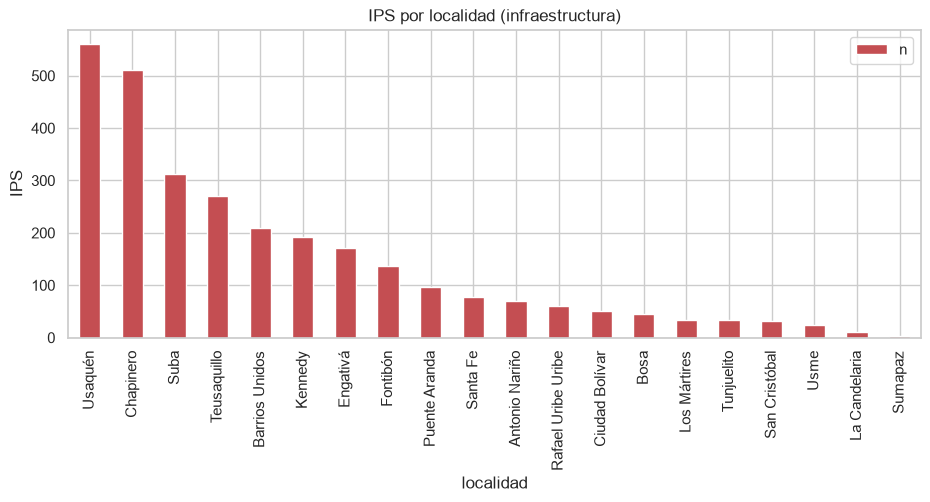

In [ ]:
from src.eda.spatial import load_loca, count_points_by_locality
ips_infra = gpd.read_file(str(RAW_DIR / "INFRAESTRUCTURA_ESPACIO_PUBLICO" / "ips.gpkg"), layer="ips")
conteo2 = count_points_by_locality(ips_infra, load_loca(MR_PATH)).sort_values("n", ascending=False).reset_index(drop=True)
conteo2.to_csv(REPORTS / "infra_ips_por_localidad.csv", index=False)
display(conteo2)
print("Total IPS:", len(ips_infra), "| localidades con IPS:", conteo2["localidad"].notna().sum())
conteo2.plot(x="localidad", y="n", kind="bar", figsize=(11, 4), title="IPS por localidad (infraestructura)", color="#c44e52")
plt.ylabel("IPS")
plt.show()


## 6. Indicadores del sector

In [ ]:
sts = eda.indicator_status()
sts_sec = sts[sts["indicador"].str.startswith("INF", na=False)]
display(sts_sec[["indicador", "dimension", "estado", "que_falta"]])
sts_sec.to_csv(REPORTS / "indicadores_infraestructura.csv", index=False)
guardar_tiempos("05_eda_infraestructura.csv")
print("Secciones del notebook:", list(_SECTION_T.keys()))


,indicador,dimension,estado,que_falta


tiempos guardados: 05_eda_infraestructura.csv (3 secciones)
Secciones del notebook: ['parques', 'estado_vias', 'ips_infra']
